# 07 - Feature Importance Analysis
Analyze which connections are most important for classification.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

PROJECT_ROOT = Path('/home/sjoon/projects/brain_connectivity_classifier')
RESULTS_DIR = PROJECT_ROOT / 'data' / 'results'
ANALYSIS_DIR = PROJECT_ROOT / 'data' / 'analysis'
FIGURES_DIR = PROJECT_ROOT / 'figures' / 'feature_importance'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Trained Models

In [2]:
# Load final model
model_path = RESULTS_DIR / 'full_connectivity_analysis' / 'task_testing' / 'final_model.pkl'
with open(model_path, 'rb') as f:
    model = pickle.load(f)

print(f"Loaded model: {type(model)}")
print(f"Model has {len(model.coef_)} classes")
print(f"Feature shape: {model.coef_.shape}")

Loaded model: <class 'sklearn.linear_model._logistic.LogisticRegression'>
Model has 232 classes
Feature shape: (232, 232)


## 2. Analyze Coefficients

In [3]:
# Get mean absolute coefficient per feature
mean_abs_coef = np.abs(model.coef_).mean(axis=0)

# Get top features
top_indices = np.argsort(mean_abs_coef)[-20:][::-1]

print("Top 20 Most Important Features (connections):")
for i, idx in enumerate(top_indices, 1):
    print(f"{i:2d}. Feature {idx:4d}: {mean_abs_coef[idx]:.6f}")

Top 20 Most Important Features (connections):
 1. Feature  192: 0.125343
 2. Feature  175: 0.124617
 3. Feature  157: 0.123832
 4. Feature   49: 0.123447
 5. Feature   93: 0.120026
 6. Feature   69: 0.119831
 7. Feature   24: 0.119627
 8. Feature   40: 0.118346
 9. Feature   94: 0.118268
10. Feature   57: 0.118036
11. Feature   89: 0.117947
12. Feature  176: 0.117655
13. Feature   66: 0.117300
14. Feature   85: 0.117131
15. Feature   72: 0.116445
16. Feature  113: 0.116384
17. Feature   91: 0.115676
18. Feature  228: 0.115633
19. Feature   62: 0.115509
20. Feature   43: 0.115507


## 3. Visualization

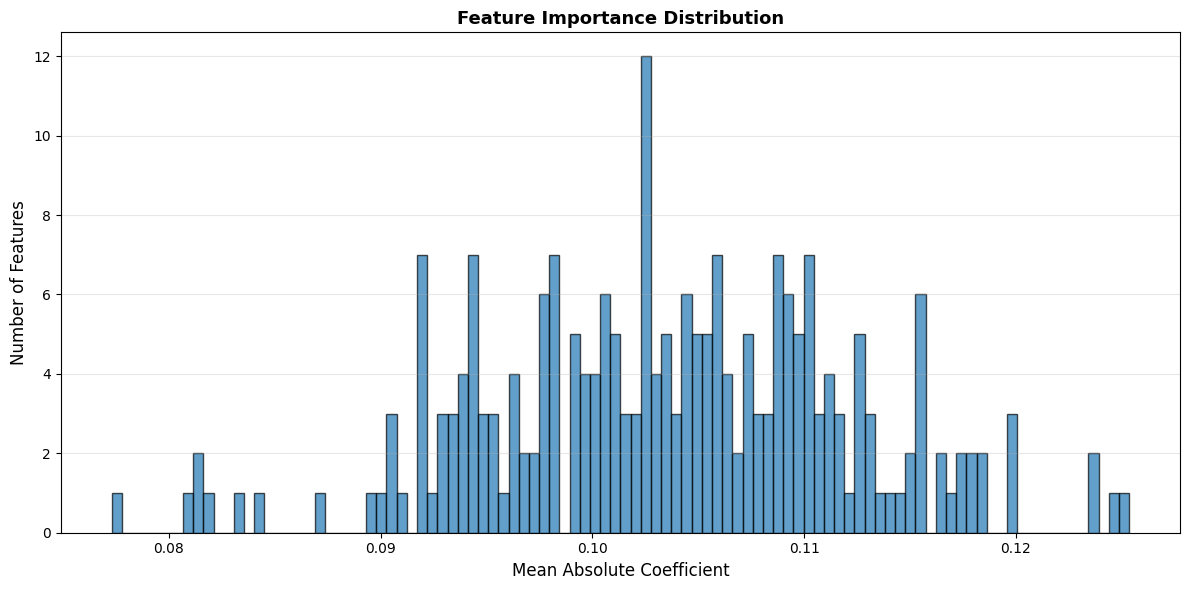

Feature importance analysis complete!


In [4]:
# Plot feature importance distribution
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(mean_abs_coef, bins=100, edgecolor='black', alpha=0.7)
ax.set_xlabel('Mean Absolute Coefficient', fontsize=12)
ax.set_ylabel('Number of Features', fontsize=12)
ax.set_title('Feature Importance Distribution', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_importance_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Feature importance analysis complete!")